In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

!pip install -q captum
from captum.attr import LayerGradCam
from captum.attr import visualization as viz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 74.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 

In [4]:
import glob
import os


base_path = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'


image_files = glob.glob(os.path.join(base_path, '**/*.jpg'), recursive=True)

if len(image_files) > 0:
    img_path = image_files[0]
    print(f"Success! Found image at: {img_path}")
    input_tensor, original_image = preprocess_image(img_path)
else:
    print("Error: Dataset not found. Please click '+ Add Input' on the right panel.")

Success! Found image at: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


Model Predicted Class Index: 318
Visualization Error: axis 2 is out of bounds for array of dimension 2


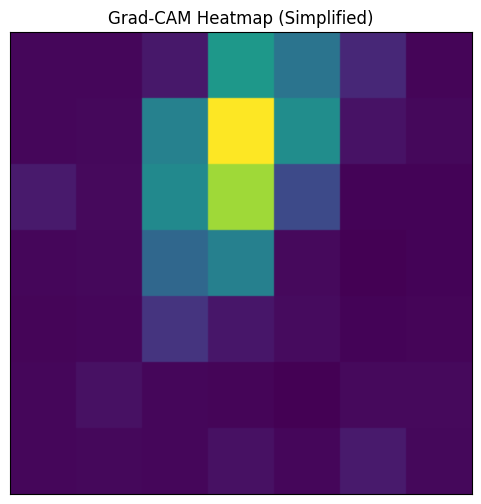

In [11]:

def prepare_for_vis(tensor):
    
    data = tensor.squeeze().cpu().detach().numpy()
    
    if len(data.shape) == 3:
        return np.transpose(data, (1, 2, 0))
    return data 

vis_attr = prepare_for_vis(upsampled_attr)
vis_img = prepare_for_vis(input_tensor)


print(f"Model Predicted Class Index: {pred_label_idx.item()}")

try:
    _ = viz.visualize_image_attr(
        vis_attr,
        vis_img,
        method="heatmap",
        sign="all",
        show_colorbar=True,
        title="Explainable AI: Grad-CAM Visualization"
    )
except Exception as e:
    print(f"Visualization Error: {e}")
   
    plt.imshow(vis_attr)
    plt.title("Grad-CAM Heatmap (Simplified)")
    plt.show()